# Exploratory Data Analysis for TEMP features

import pickle

def read_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f)
        return data

In [2]:
path = "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES140/Lab/Features/arithmetix_easy/TEMP_features_30_sec.pickle"


In [4]:
import pickle

def read_file(filename):
    with open(filename, "rb") as f:
        data = pickle.load(f)
        return data

In [7]:
TEMP_30 = read_file(path)

In [8]:
TEMP_30.head()

,mean_temp,std_temp
0,27.196667,0.013984
1,27.196667,0.013984
2,27.200000,0.016125
3,27.202833,0.015874
4,27.204667,0.015434


In [9]:
TEMP_30.columns

Index(['mean_temp', 'std_temp'], dtype='object')

In [10]:
for column in TEMP_30.columns:
    #print data type of column
    print(f"{column}: {TEMP_30[column].dtype}")

mean_temp: float64
std_temp: float64


In [11]:
TEMP_30.describe()

,mean_temp,std_temp
count,96.000000,96.000000
mean,27.142970,0.013619
std,0.062425,0.003591
min,27.044833,0.008081
25%,27.077667,0.011401
50%,27.136500,0.012818
75%,27.203292,0.015448
max,27.233000,0.027536


array([[<Axes: title={'center': 'mean_temp'}>,
        <Axes: title={'center': 'std_temp'}>]], dtype=object)

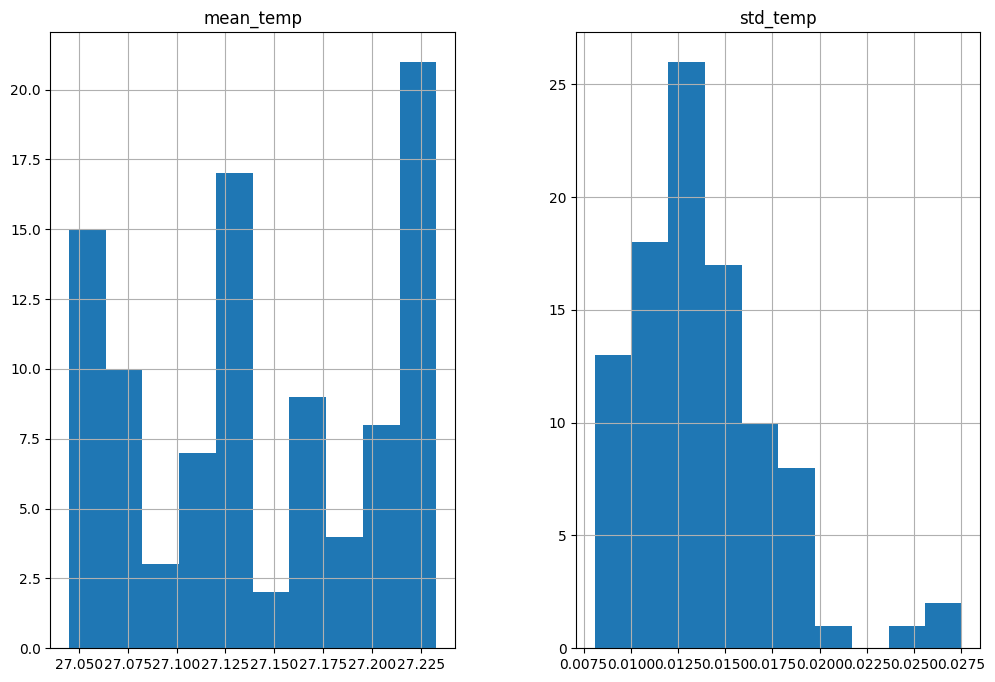

In [12]:
TEMP_30.hist(figsize=(12,8))

In [15]:
import os
import pickle
import pandas as pd


base_path = "/Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress"

patient_ids = ["140", "141", "247", "257", "260","313","362","404","437","446","491"]


tasks = {
    "arithmetix_easy": "easy",
    "arithmetix_hard": "hard",
    "relaxation_video": "relaxation"
}

feature_columns = ['mean_temp', 'std_temp']

def read_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

all_data = []

for patient_id in patient_ids:

    for task_folder, task_label in tasks.items():

        path = os.path.join(
            base_path,
            "ES"+patient_id,
            "Lab",
            "Features",
            task_folder,
            "TEMP_features_30_sec.pickle"
        )

        
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue

        
        df = read_pickle(path).copy()

       
        df = df[feature_columns].copy()

       
        df["task_label"] = task_label
        df["patient_id"] = patient_id

        all_data.append(df)

        print(
            f"{patient_id} | {task_label} | "
            f"{df.shape[0]} windows"
        )


TEMP_all = pd.concat(
    all_data,
    ignore_index=True
)

print("\nFinal shape:", PPG_all.shape)

TEMP_all.head()

140 | easy | 96 windows
140 | hard | 96 windows
140 | relaxation | 96 windows
141 | easy | 96 windows
141 | hard | 96 windows
141 | relaxation | 96 windows
Missing: /Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES247/Lab/Features/arithmetix_easy/TEMP_features_30_sec.pickle
Missing: /Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES247/Lab/Features/arithmetix_hard/TEMP_features_30_sec.pickle
Missing: /Users/krisha/Projs/Neuro-brain-states/Datasets/EPIStress/ES247/Lab/Features/relaxation_video/TEMP_features_30_sec.pickle
257 | easy | 96 windows
257 | hard | 96 windows
257 | relaxation | 96 windows
260 | easy | 96 windows
260 | hard | 96 windows
260 | relaxation | 95 windows
313 | easy | 96 windows
313 | hard | 96 windows
313 | relaxation | 96 windows
362 | easy | 96 windows
362 | hard | 96 windows
362 | relaxation | 96 windows
404 | easy | 97 windows
404 | hard | 100 windows
404 | relaxation | 96 windows
437 | easy | 101 windows
437 | hard | 96 windows
437 | relaxat

,mean_temp,std_temp,task_label,patient_id
0,27.196667,0.013984,easy,140
1,27.196667,0.013984,easy,140
2,27.200000,0.016125,easy,140
3,27.202833,0.015874,easy,140
4,27.204667,0.015434,easy,140


In [16]:
TEMP_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2709 entries, 0 to 2708
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   mean_temp   2709 non-null   float64
 1   std_temp    2709 non-null   float64
 2   task_label  2709 non-null   object 
 3   patient_id  2709 non-null   object 
dtypes: float64(2), object(2)
memory usage: 84.8+ KB


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

distribution_stats = TEMP_all[feature_columns].describe().T

distribution_stats["skewness"] = TEMP_all[feature_columns].skew()
distribution_stats["kurtosis"] = TEMP_all[feature_columns].kurtosis()

distribution_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
mean_temp,2709.0,31.783744,2.367125,26.572667,29.794000,32.721167,33.527750,35.115583,-0.691739,-0.692161
std_temp,2709.0,0.020438,0.015280,0.004819,0.013149,0.015950,0.021005,0.208726,4.463639,28.346465


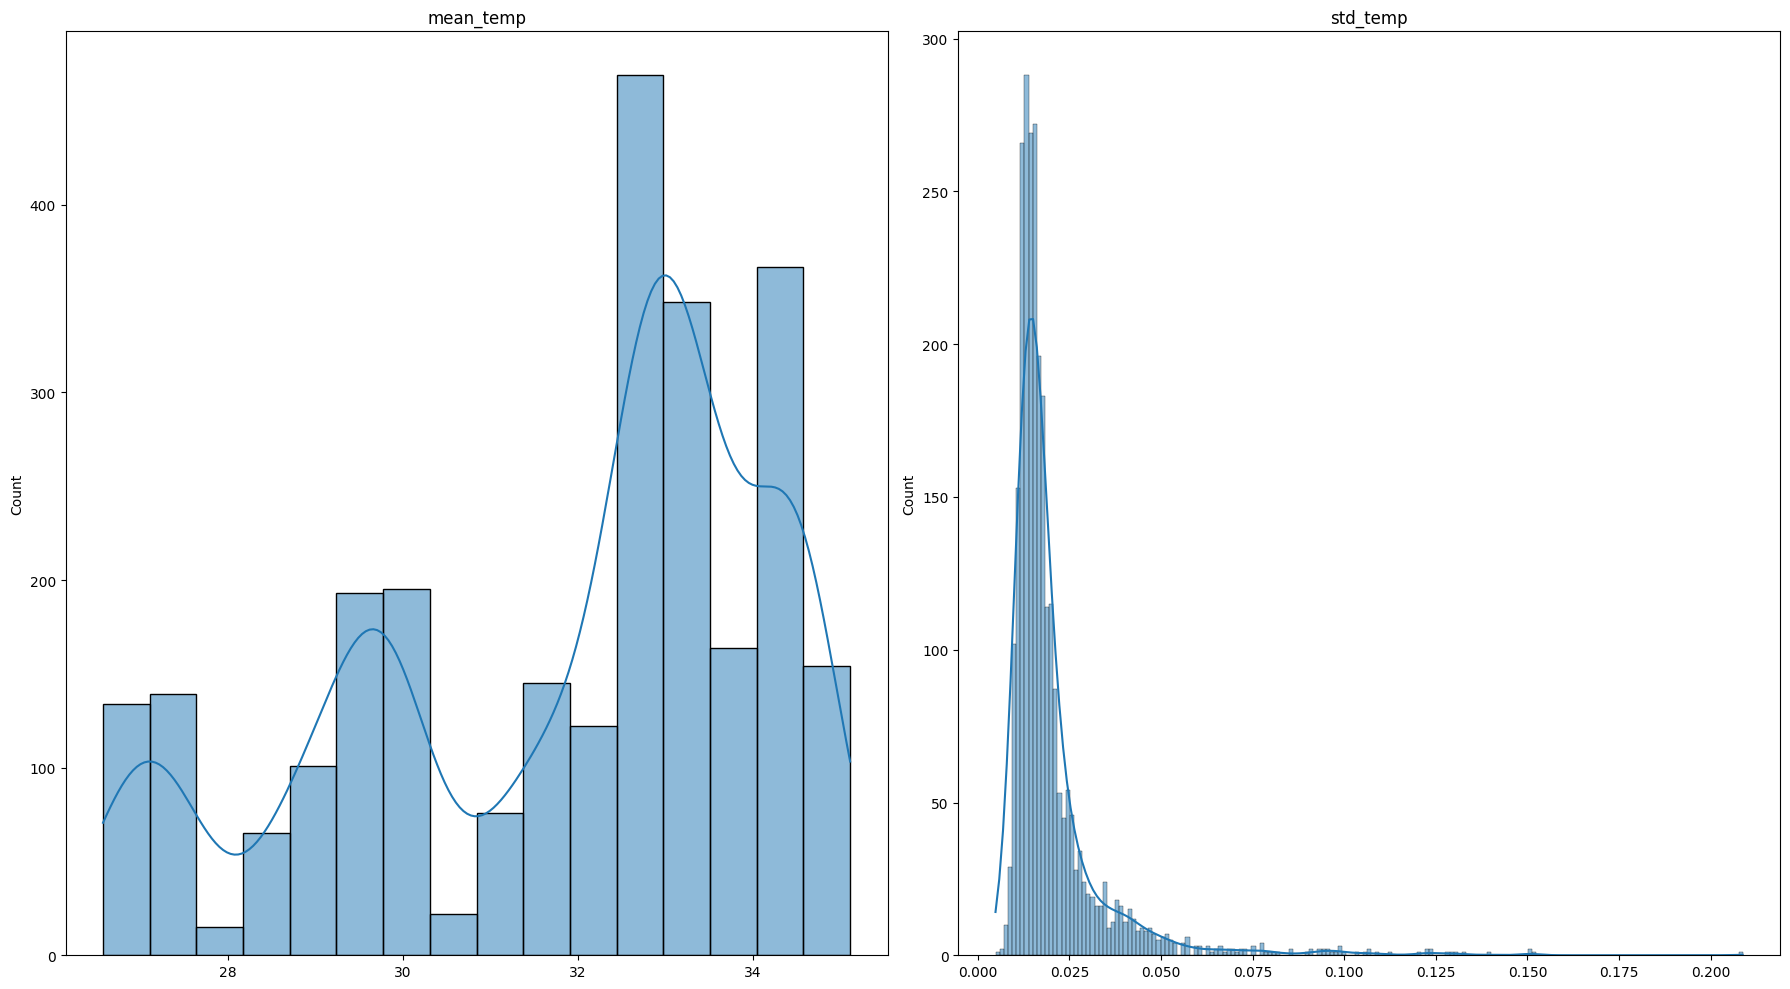

In [19]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):

    sns.histplot(
        data=PPG_all,
        x=feature,
        kde=True,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

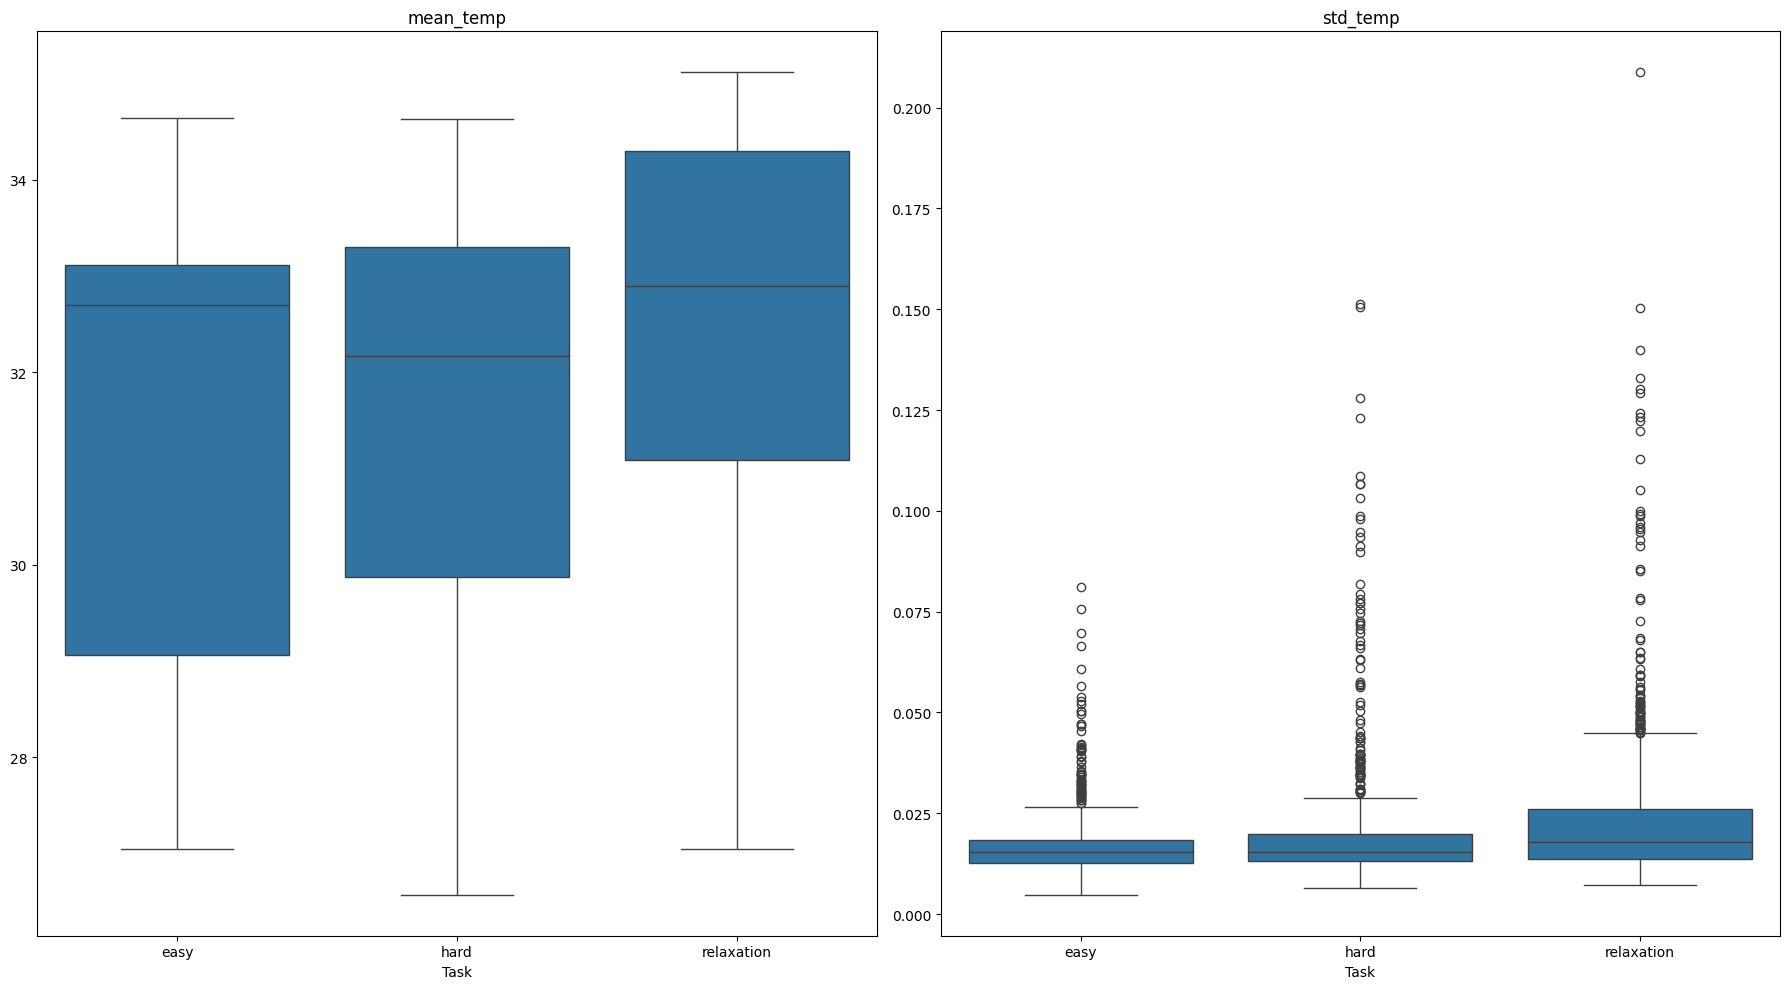

In [20]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):

    sns.boxplot(
        data=PPG_all,
        x="task_label",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Task")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [21]:
patient_task_means = (
    TEMP_all
    .groupby(["patient_id", "task_label"])[feature_columns]
    .mean()
    .reset_index()
)

patient_task_means.head()

,patient_id,task_label,mean_temp,std_temp
0,140,easy,27.142970,0.013619
1,140,hard,26.708571,0.017945
2,140,relaxation,27.447783,0.020797
3,141,easy,33.049263,0.015312
4,141,hard,32.864009,0.013900


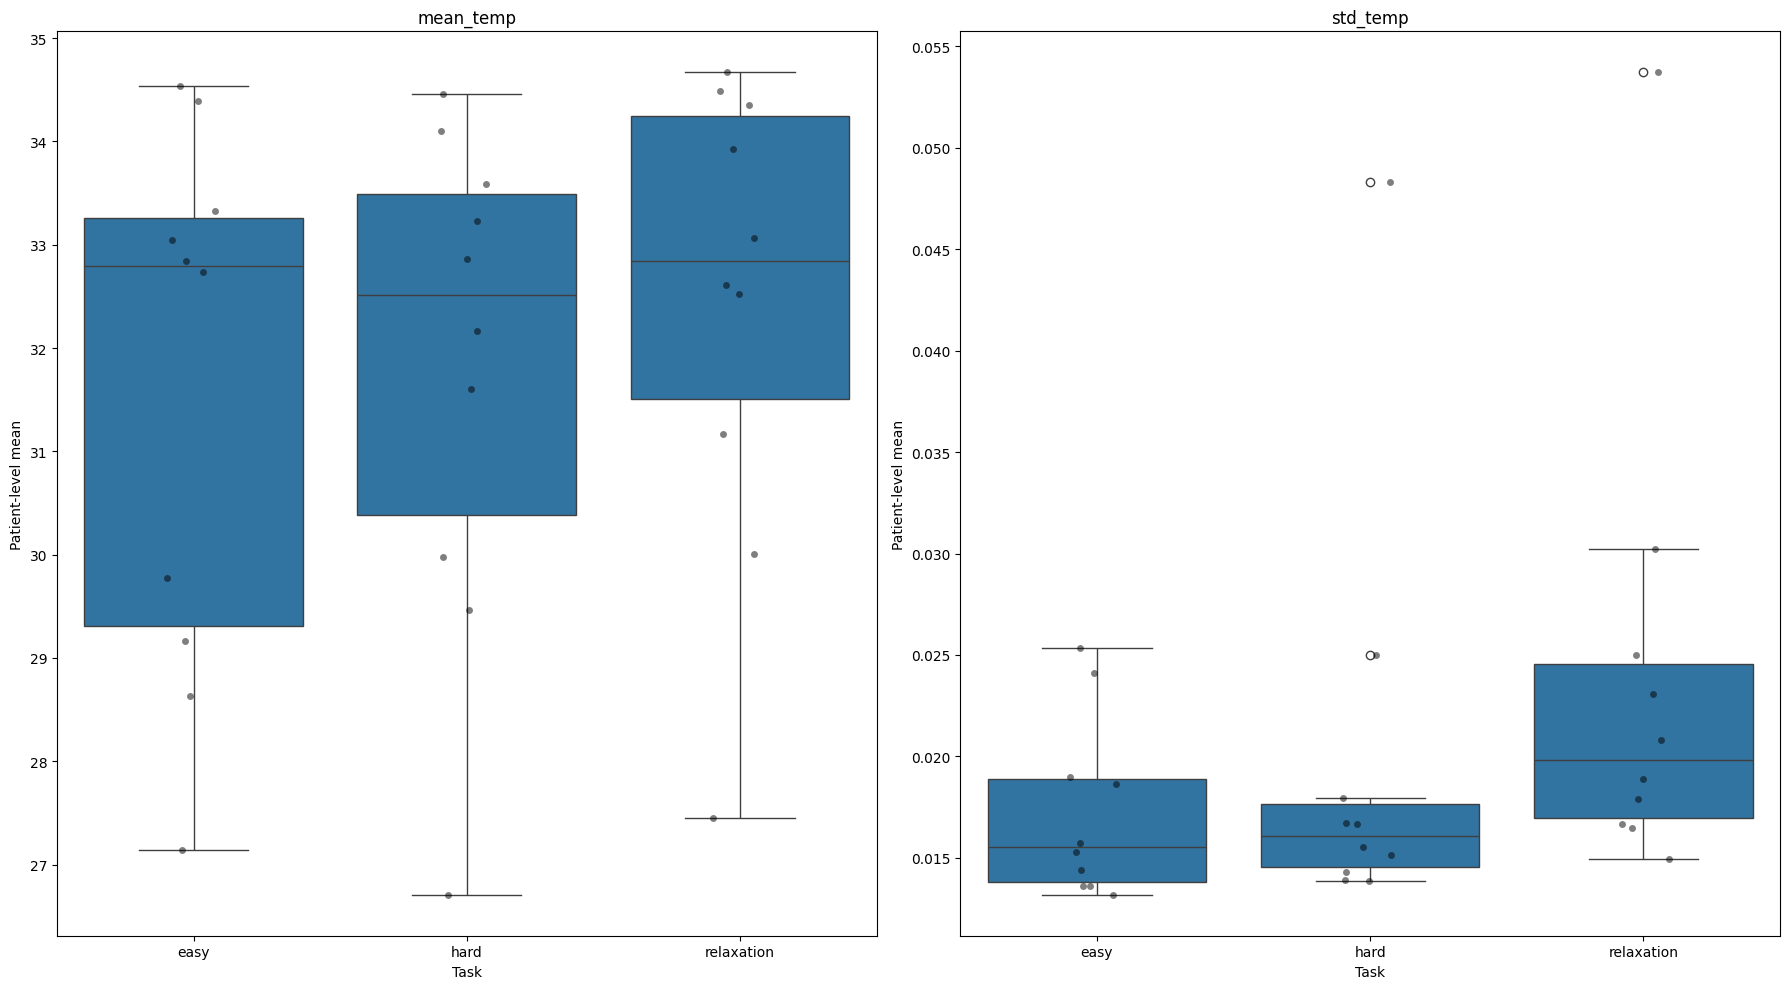

In [23]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 10)
)

axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):

    sns.boxplot(
        data=patient_task_means,
        x="task_label",
        y=feature,
        ax=ax
    )

    sns.stripplot(
        data=patient_task_means,
        x="task_label",
        y=feature,
        color="black",
        alpha=0.5,
        ax=ax
    )

    ax.set_title(feature)
    ax.set_xlabel("Task")
    ax.set_ylabel("Patient-level mean")

plt.tight_layout()
plt.show()

In [24]:
outlier_summary = []

for feature in feature_columns:

    Q1 = TEMP_all[feature].quantile(0.25)
    Q3 = TEMP_all[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (TEMP_all[feature] < lower_bound) |
        (TEMP_all[feature] > upper_bound)
    )

    outlier_summary.append({
        "feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "n_outliers": outliers.sum(),
        "outlier_percentage": 100 * outliers.mean()
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,feature,Q1,Q3,IQR,lower_bound,upper_bound,n_outliers,outlier_percentage
0,mean_temp,29.794000,33.527750,3.733750,24.193375,39.128375,0,0.000000
1,std_temp,0.013149,0.021005,0.007857,0.001364,0.032790,285,10.520487


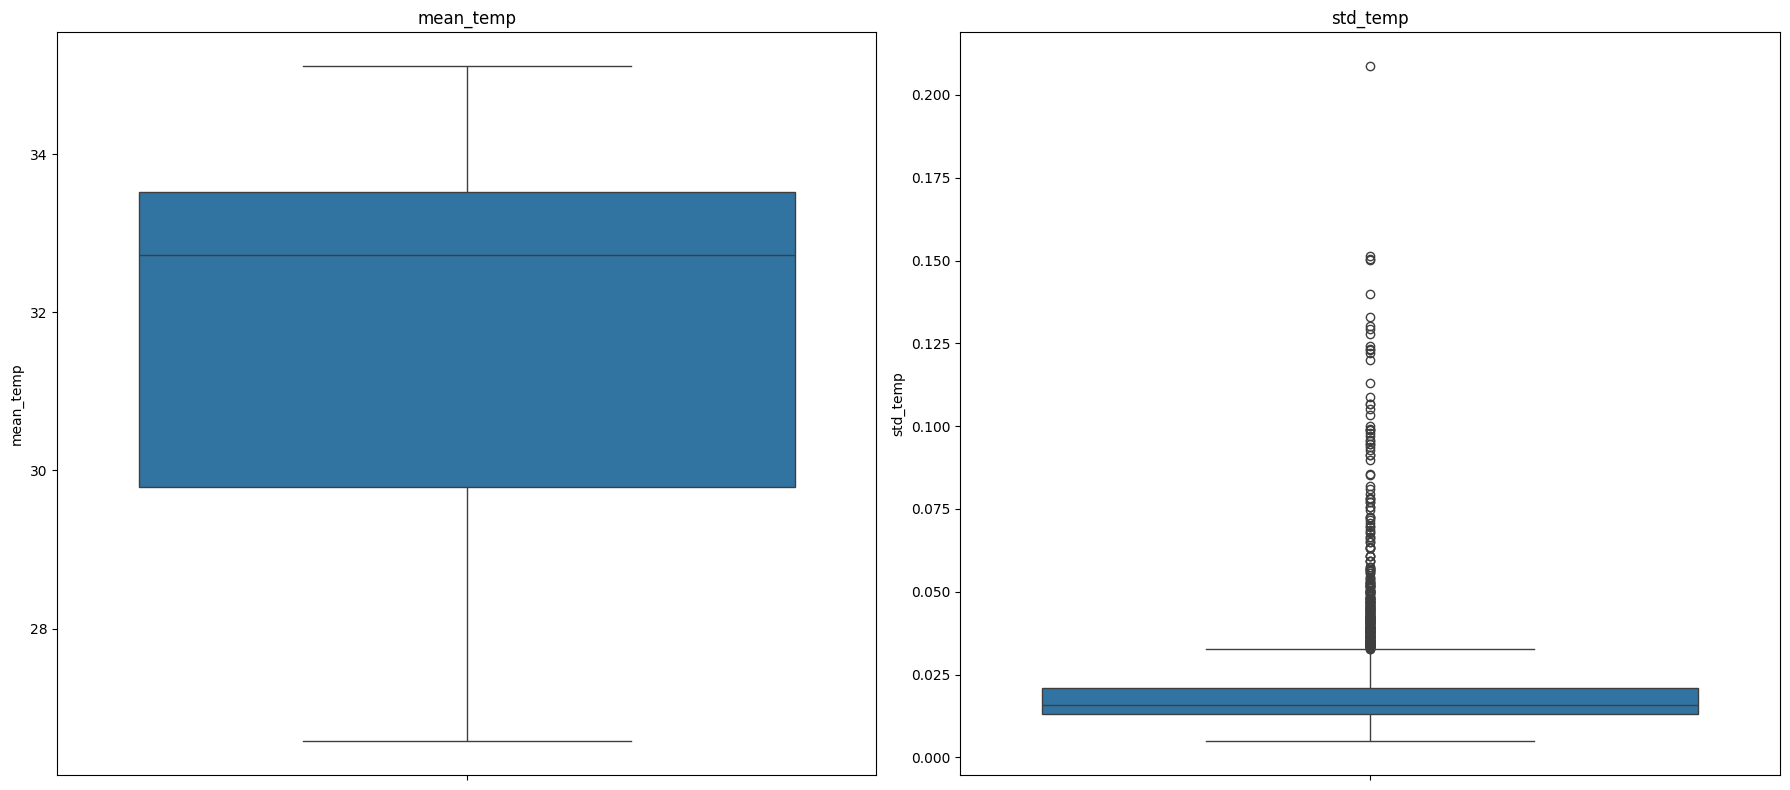

In [25]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 8)
)

axes = axes.flatten()

for ax, feature in zip(axes, feature_columns):

    sns.boxplot(
        data=TEMP_all,
        y=feature,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [26]:
patient_outliers = []

for feature in feature_columns:

    Q1 = TEMP_all[feature].quantile(0.25)
    Q3 = TEMP_all[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    temp = TEMP_all.copy()

    temp["is_outlier"] = (
        (temp[feature] < lower) |
        (temp[feature] > upper)
    )

    summary = (
        temp
        .groupby("patient_id")["is_outlier"]
        .mean()
        .reset_index()
    )

    summary["feature"] = feature

    patient_outliers.append(summary)

patient_outliers = pd.concat(
    patient_outliers,
    ignore_index=True
)

patient_outliers.head()

,patient_id,is_outlier,feature
0,140,0.0,mean_temp
1,141,0.0,mean_temp
2,257,0.0,mean_temp
3,260,0.0,mean_temp
4,313,0.0,mean_temp


In [27]:
correlation_matrix = TEMP_all[
    feature_columns
].corr(method="spearman")

correlation_matrix

,mean_temp,std_temp
mean_temp,1.00000,0.05241
std_temp,0.05241,1.00000


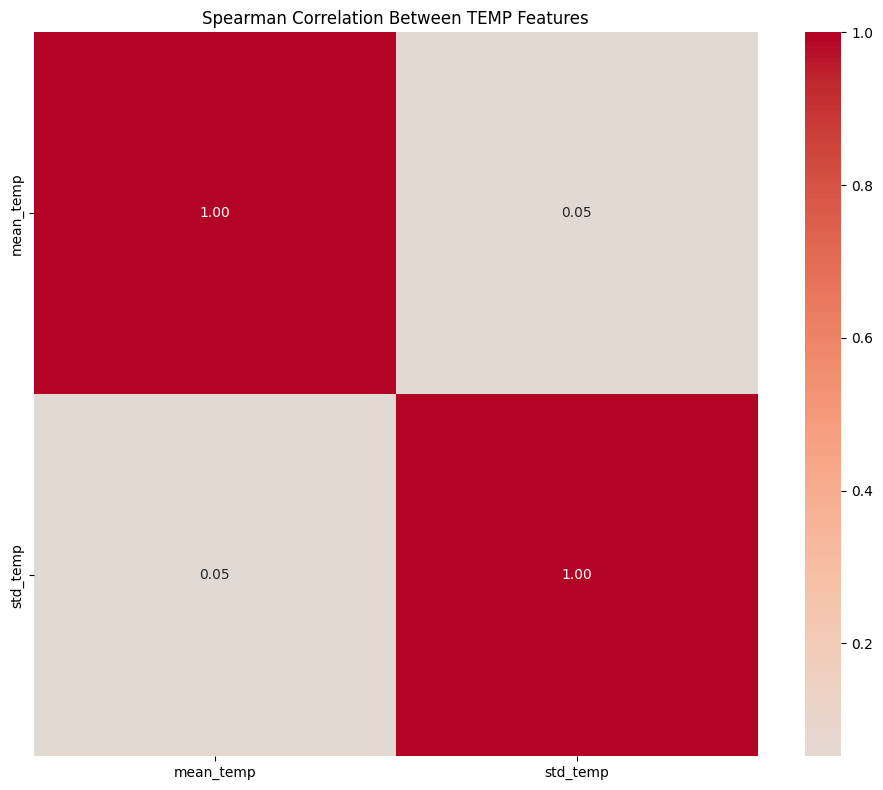

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Spearman Correlation Between TEMP Features")
plt.tight_layout()
plt.show()

In [29]:
high_corr_pairs = []

for i in range(len(feature_columns)):

    for j in range(i + 1, len(feature_columns)):

        feature_1 = feature_columns[i]
        feature_2 = feature_columns[j]

        rho = correlation_matrix.loc[
            feature_1,
            feature_2
        ]

        if abs(rho) >= 0.85:

            high_corr_pairs.append({
                "feature_1": feature_1,
                "feature_2": feature_2,
                "spearman_rho": rho
            })

high_corr_pairs = pd.DataFrame(
    high_corr_pairs
)

high_corr_pairs

""


In [30]:
from scipy.stats import kruskal

kruskal_results = []

for feature in feature_columns:

    groups = [
        group[feature].dropna().values
        for _, group in patient_task_means.groupby("task_label")
    ]

    statistic, p_value = kruskal(*groups)

    kruskal_results.append({
        "feature": feature,
        "H_statistic": statistic,
        "p_value": p_value
    })

kruskal_results = pd.DataFrame(
    kruskal_results
)

kruskal_results

,feature,H_statistic,p_value
0,mean_temp,0.714839,0.699479
1,std_temp,4.353548,0.113407


In [31]:
from scipy.stats import mannwhitneyu

task_pairs = [
    ("easy", "hard"),
    ("easy", "relaxation"),
    ("hard", "relaxation")
]

pairwise_results = []

for feature in feature_columns:

    for task_1, task_2 in task_pairs:

        x = patient_task_means.loc[
            patient_task_means["task_label"] == task_1,
            feature
        ].dropna()

        y = patient_task_means.loc[
            patient_task_means["task_label"] == task_2,
            feature
        ].dropna()

        statistic, p_value = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        pairwise_results.append({
            "feature": feature,
            "comparison": f"{task_1} vs {task_2}",
            "U_statistic": statistic,
            "p_value": p_value,
            "n_1": len(x),
            "n_2": len(y)
        })

pairwise_results = pd.DataFrame(
    pairwise_results
)

pairwise_results

,feature,comparison,U_statistic,p_value,n_1,n_2
0,mean_temp,easy vs hard,47.0,0.850107,10,10
1,mean_temp,easy vs relaxation,41.0,0.520523,10,10
2,mean_temp,hard vs relaxation,40.0,0.472676,10,10
3,std_temp,easy vs hard,45.0,0.733730,10,10
4,std_temp,easy vs relaxation,26.0,0.075662,10,10
5,std_temp,hard vs relaxation,27.0,0.088973,10,10


In [32]:
def rank_biserial_correlation(x, y):

    U, _ = mannwhitneyu(
        x,
        y,
        alternative="two-sided"
    )

    n1 = len(x)
    n2 = len(y)

    rbc = (2 * U) / (n1 * n2) - 1

    return rbc

In [33]:
pairwise_results = []

for feature in feature_columns:

    for task_1, task_2 in task_pairs:

        x = patient_task_means.loc[
            patient_task_means["task_label"] == task_1,
            feature
        ].dropna()

        y = patient_task_means.loc[
            patient_task_means["task_label"] == task_2,
            feature
        ].dropna()

        statistic, p_value = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        effect_size = rank_biserial_correlation(x, y)

        pairwise_results.append({
            "feature": feature,
            "comparison": f"{task_1} vs {task_2}",
            "U_statistic": statistic,
            "p_value": p_value,
            "effect_size": effect_size,
            "n_1": len(x),
            "n_2": len(y)
        })

pairwise_results = pd.DataFrame(
    pairwise_results
)

pairwise_results

,feature,comparison,U_statistic,p_value,effect_size,n_1,n_2
0,mean_temp,easy vs hard,47.0,0.850107,-0.06,10,10
1,mean_temp,easy vs relaxation,41.0,0.520523,-0.18,10,10
2,mean_temp,hard vs relaxation,40.0,0.472676,-0.20,10,10
3,std_temp,easy vs hard,45.0,0.733730,-0.10,10,10
4,std_temp,easy vs relaxation,26.0,0.075662,-0.48,10,10
5,std_temp,hard vs relaxation,27.0,0.088973,-0.46,10,10


In [34]:
from statsmodels.stats.multitest import multipletests

reject, p_fdr, _, _ = multipletests(
    pairwise_results["p_value"],
    method="fdr_bh"
)

pairwise_results["p_fdr"] = p_fdr
pairwise_results["significant_fdr"] = reject

In [35]:
pairwise_results.sort_values(
    "p_fdr"
)

,feature,comparison,U_statistic,p_value,effect_size,n_1,n_2,p_fdr,significant_fdr
4,std_temp,easy vs relaxation,26.0,0.075662,-0.48,10,10,0.266919,False
5,std_temp,hard vs relaxation,27.0,0.088973,-0.46,10,10,0.266919,False
1,mean_temp,easy vs relaxation,41.0,0.520523,-0.18,10,10,0.780784,False
2,mean_temp,hard vs relaxation,40.0,0.472676,-0.20,10,10,0.780784,False
0,mean_temp,easy vs hard,47.0,0.850107,-0.06,10,10,0.850107,False
3,std_temp,easy vs hard,45.0,0.733730,-0.10,10,10,0.850107,False


In [36]:
reject, p_fdr, _, _ = multipletests(
    kruskal_results["p_value"],
    method="fdr_bh"
)

kruskal_results["p_fdr"] = p_fdr
kruskal_results["significant_fdr"] = reject

kruskal_results.sort_values("p_fdr")

,feature,H_statistic,p_value,p_fdr,significant_fdr
1,std_temp,4.353548,0.113407,0.226814,False
0,mean_temp,0.714839,0.699479,0.699479,False


In [37]:
statistical_summary = kruskal_results[
    [
        "feature",
        "H_statistic",
        "p_value",
        "p_fdr",
        "significant_fdr"
    ]
].copy()

statistical_summary

,feature,H_statistic,p_value,p_fdr,significant_fdr
0,mean_temp,0.714839,0.699479,0.699479,False
1,std_temp,4.353548,0.113407,0.226814,False


In [38]:
pairwise_summary = pairwise_results[
    [
        "feature",
        "comparison",
        "p_value",
        "p_fdr",
        "effect_size",
        "significant_fdr"
    ]
].sort_values("p_fdr")

pairwise_summary

,feature,comparison,p_value,p_fdr,effect_size,significant_fdr
4,std_temp,easy vs relaxation,0.075662,0.266919,-0.48,False
5,std_temp,hard vs relaxation,0.088973,0.266919,-0.46,False
1,mean_temp,easy vs relaxation,0.520523,0.780784,-0.18,False
2,mean_temp,hard vs relaxation,0.472676,0.780784,-0.20,False
0,mean_temp,easy vs hard,0.850107,0.850107,-0.06,False
3,std_temp,easy vs hard,0.733730,0.850107,-0.10,False


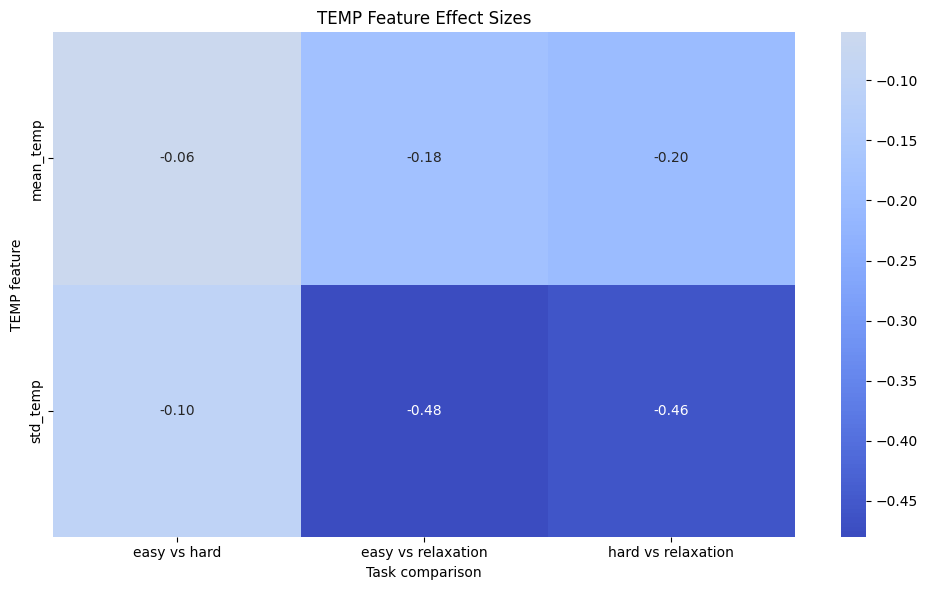

In [40]:
effect_size_matrix = pairwise_results.pivot(
    index="feature",
    columns="comparison",
    values="effect_size"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    effect_size_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("TEMP Feature Effect Sizes")
plt.xlabel("Task comparison")
plt.ylabel("TEMP feature")

plt.tight_layout()
plt.show()

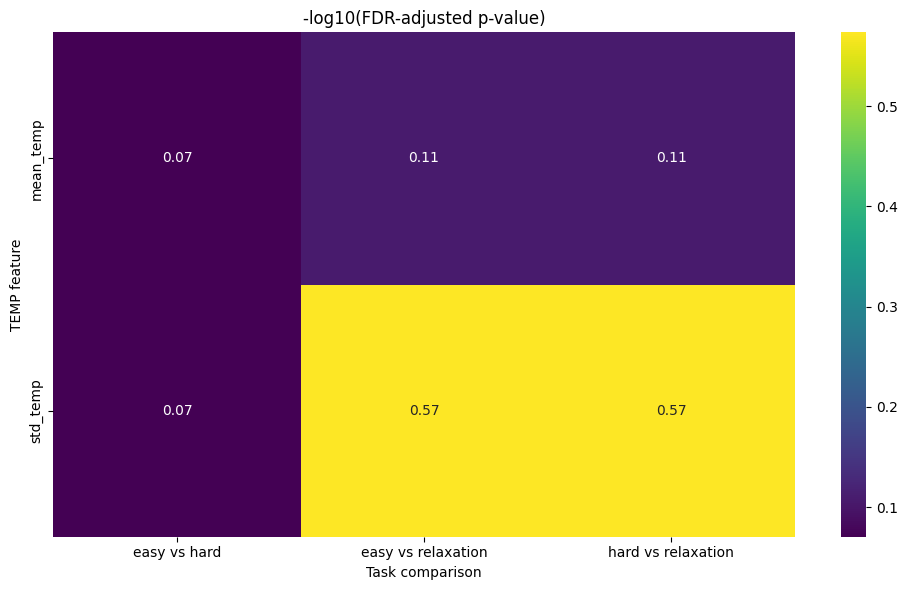

In [41]:
pvalue_matrix = pairwise_results.pivot(
    index="feature",
    columns="comparison",
    values="p_fdr"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    -np.log10(pvalue_matrix),
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("-log10(FDR-adjusted p-value)")
plt.xlabel("Task comparison")
plt.ylabel("TEMP feature")

plt.tight_layout()
plt.show()